<a href="https://colab.research.google.com/github/AslesaLamsal/AI-and-Machine-Learning/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Artificial Intelligence and Machine Learning.
Implementation of Convolutional Neural Network using Keras.**

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and Machine Learning/Week5/Copy of FruitinAmazon.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [ ]:
import os
os.listdir("/content/data")

['FruitinAmazon']

**Implement an End to End CNN Model for Image Classification Task.**

**Task 1: Data Understanding and Visualization:**

**Load and visualize images from a dataset stored in directories, where each subdirectory represents a class.**

**• Get the list of class directories from the train folder.**

**• Select one image randomly from each class.**

**• Display the images in a grid format with two rows using matplotlib.**

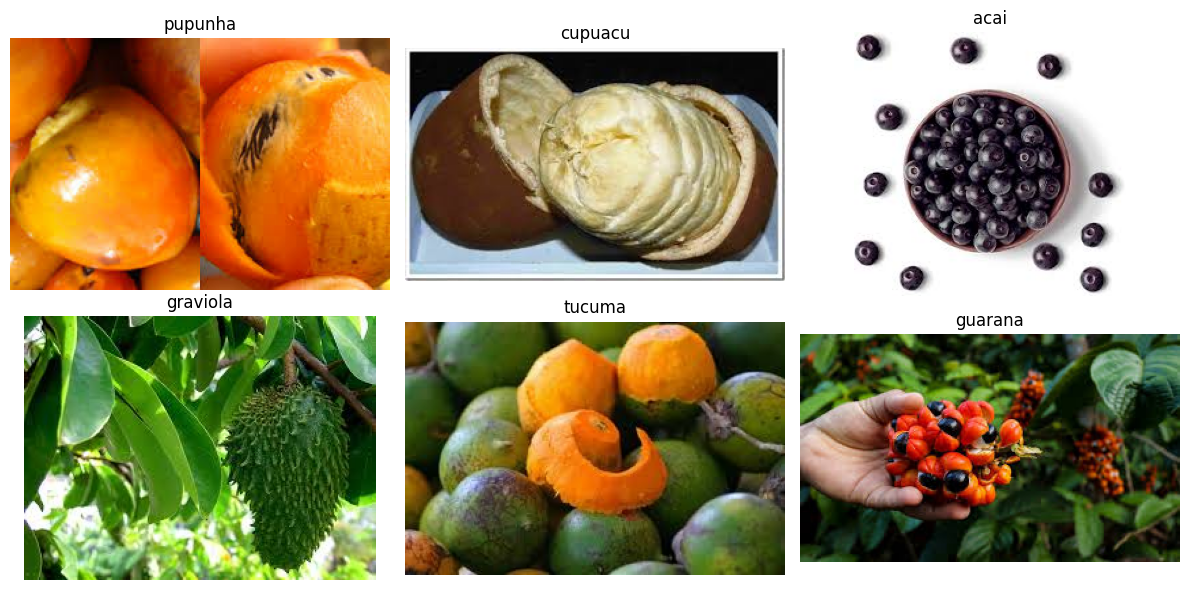

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_dir = '/content/data/FruitinAmazon/train'

classes = []
for folder_name in os.listdir(train_dir):
    if os.path.isdir(os.path.join(train_dir, folder_name)):
        classes.append(folder_name)

num_classes = len(classes)
cols = (num_classes + 1) // 2  # Calculate how many columns we need for 2 rows
fig, axes = plt.subplots(nrows=2, ncols=cols, figsize=(12, 6))

# Flatten the axes array to easily loop through it
axes = axes.flatten()

# 2. Select one image randomly from each class and 3. Display them
for i in range(len(classes)):
    class_name = classes[i]
    class_path = os.path.join(train_dir, class_name)

    # Get a list of all files in this class folder
    all_images = os.listdir(class_path)

    # Make sure the folder is not empty
    if len(all_images) > 0:
        # Select one random image
        random_image_name = random.choice(all_images)
        image_path = os.path.join(class_path, random_image_name)

        # Load and display the image
        img = mpimg.imread(image_path)
        axes[i].imshow(img)
        axes[i].set_title(class_name)
        axes[i].axis('off') # Hide the axis ticks

# Hide any extra empty plots if you have an odd number of classes
for j in range(len(classes), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
from PIL import Image

# Define the path to your training folder
train_dir = '/content/data/FruitinAmazon/train'

# Maintain a list of all corrupted image paths for reporting
corrupted_images = []

# Iterate through each class subdirectory
for class_folder in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_folder)

    # Make sure we are only looking inside directories
    if os.path.isdir(class_path):

        # Check each image inside this class folder
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            try:
                # Use Image.open() to attempt to load each image
                img = Image.open(image_path)
                img.verify() # This specifically verifies if the image is valid
            except (IOError, SyntaxError):
                # If the image is corrupted, remove it
                os.remove(image_path)
                corrupted_images.append(image_path)
                print(f"Removed corrupted image: {image_path}")
# Reporting the final outcome
if len(corrupted_images) == 0:
    print("No corrupted images found.")


No corrupted images found.


**Task 2: Loading and Preprocessing Image Data in keras:**

In [ ]:
import tensorflow as tf

# Define image size and batch size
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)
# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]

# Apply the normalization (Rescaling) to the datasetand validation dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


**Task 3 - Implement a CNN with**

**Convolutional Architecture:**

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Convolutional Layer 1
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', strides=1, activation='relu', input_shape=(128, 128, 3)),
    # Pooling Layer 1
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', strides=1, activation='relu'),
    # Pooling Layer 2
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),


    # Flatten Layer
    layers.Flatten(),

    # Hidden Layer 1
    layers.Dense(64, activation='relu'),

    # Hidden Layer 2 (
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

**Task 4: Compile the Model**

**• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).**

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully!")

Model compiled successfully!


**Task 4: Train the Model**

**Model Training**

**• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.**

**• Use val ds for validation.**

**• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid-
ing overfitting.**

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'best_fruit_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.1944 - loss: 2.0518
Epoch 1: val_accuracy improved from None to 0.61111, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 788ms/step - accuracy: 0.2083 - loss: 2.1636 - val_accuracy: 0.6111 - val_loss: 1.5361
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.3750 - loss: 1.7185
Epoch 2: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 741ms/step - accuracy: 0.3750 - loss: 1.6830 - val_accuracy: 0.6111 - val_loss: 1.5333
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.5255 - loss: 1.4755
Epoch 3: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 502ms/step - accuracy: 0.5139 - loss: 1.4980 - val_accuracy: 0.3889 - val_loss: 1.4935
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.6100 - loss: 1.3102
Epoch 4: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 402ms/step - accuracy: 0.6111 - loss: 1.3010 - val_accuracy: 0.5000 - val_loss: 1.3921
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.5145 - loss:


Epoch 5: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 465ms/step - accuracy: 0.5278 - loss: 1.1483 - val_accuracy: 0.6667 - val_loss: 1.1670
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.7517 - loss: 0.9016
Epoch 6: val_accuracy did not improve from 0.66667
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 411ms/step - accuracy: 0.7083 - loss: 0.9498 - val_accuracy: 0.6111 - val_loss: 0.9660
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.7593 - loss: 0.7800
Epoch 7: val_accuracy did not improve from 0.66667
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 422ms/step - accuracy: 0.7778 - loss: 0.7564 - val_accuracy: 0.3333 - val_loss: 1.4097
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.8154 - loss: 0.5832
Epoch 8: val_accuracy improved from 0.66667 to 0.72222, saving model to best_fruit_model.h5



Epoch 8: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 448ms/step - accuracy: 0.8056 - loss: 0.5956 - val_accuracy: 0.7222 - val_loss: 0.7761
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.7789 - loss: 0.5316
Epoch 9: val_accuracy improved from 0.72222 to 0.83333, saving model to best_fruit_model.h5



Epoch 9: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 460ms/step - accuracy: 0.8056 - loss: 0.5034 - val_accuracy: 0.8333 - val_loss: 0.4658
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.8958 - loss: 0.3620
Epoch 10: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 645ms/step - accuracy: 0.8750 - loss: 0.3765 - val_accuracy: 0.6667 - val_loss: 0.9198
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 806ms/step - accuracy: 0.9294 - loss: 0.2606
Epoch 11: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 936ms/step - accuracy: 0.9444 - loss: 0.2607 - val_accuracy: 0.7778 - val_loss: 0.8134
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.8987 - loss: 0.2904
Epoch 12: val_accuracy improved from 0.83333 to 0.94444, saving model to best_fruit_model.h5



Epoch 12: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 452ms/step - accuracy: 0.9306 - loss: 0.2433 - val_accuracy: 0.9444 - val_loss: 0.3561
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9902 - loss: 0.1452
Epoch 13: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 418ms/step - accuracy: 0.9861 - loss: 0.1408 - val_accuracy: 0.8333 - val_loss: 0.4228
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 1.0000 - loss: 0.1109
Epoch 14: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 433ms/step - accuracy: 1.0000 - loss: 0.0989 - val_accuracy: 0.8333 - val_loss: 0.5732
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 1.0000 - loss: 0.0529
Epoch 15: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 419ms/step - accuracy: 1.0000 - loss: 0.0527 - val_accuracy: 0.8333 - val_loss: 0.6422
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.9954

**Task 5: Evaluate the Model**


**Model Evaluation**

**• After training, evaluate the model using model.evaluate() on the test set to check the test accuracy and loss.**

In [ ]:
#Evaluate the model on the validation/test set
test_loss, test_accuracy = model.evaluate(val_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8889 - loss: 0.3029
Test Loss: 0.3029
Test Accuracy: 0.8889


**Task 6: Save and Load the Model**

**Model Saving and Loading**

**• Save the trained model to an .h5 file using model.save().**

**• Load the saved model and re-evaluate its performance on the test set.**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

model.save('fruit_classifier_final.h5')
print("Model saved as fruit_classifier_final.h5")

# Load the saved model
loaded_model = load_model('fruit_classifier_final.h5')
print("Model loaded successfully.")

#Re-evaluate the loaded model on val_ds to confirm performance
print("Re-evaluating loaded model...")
loaded_model.evaluate(val_ds)

Model saved as fruit_classifier_final.h5


Model loaded successfully.
Re-evaluating loaded model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 976ms/step - accuracy: 0.8889 - loss: 0.3029


[0.3029385507106781, 0.8888888955116272]

**Task 7: Predictions and Classification Report**

**Making Predictions**

**• Use model.predict() to make predictions on test images.**

**• Convert the model’s predicted probabilities to digit labels using np.argmax().**

**• Also use from sklearn.metrics import classification report to report the Classification
Report of your Model Performance.**

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

#Use model.predict() to make predictions on test images
predictions = loaded_model.predict(val_ds)
predicted_labels = np.argmax(predictions, axis=1)

y_true = []
for images, labels in val_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)


unique_labels = np.unique(y_true)
target_names = [class_names[i] for i in unique_labels]

print("\n Final Classification Report")
print(classification_report(y_true, predicted_labels, labels=unique_labels, target_names=target_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step

 Final Classification Report
              precision    recall  f1-score   support

     pupunha       1.00      0.67      0.80         3
      tucuma       0.93      0.93      0.93        15

   micro avg       0.94      0.89      0.91        18
   macro avg       0.97      0.80      0.87        18
weighted avg       0.94      0.89      0.91        18



Accuracy and Loss Graphs

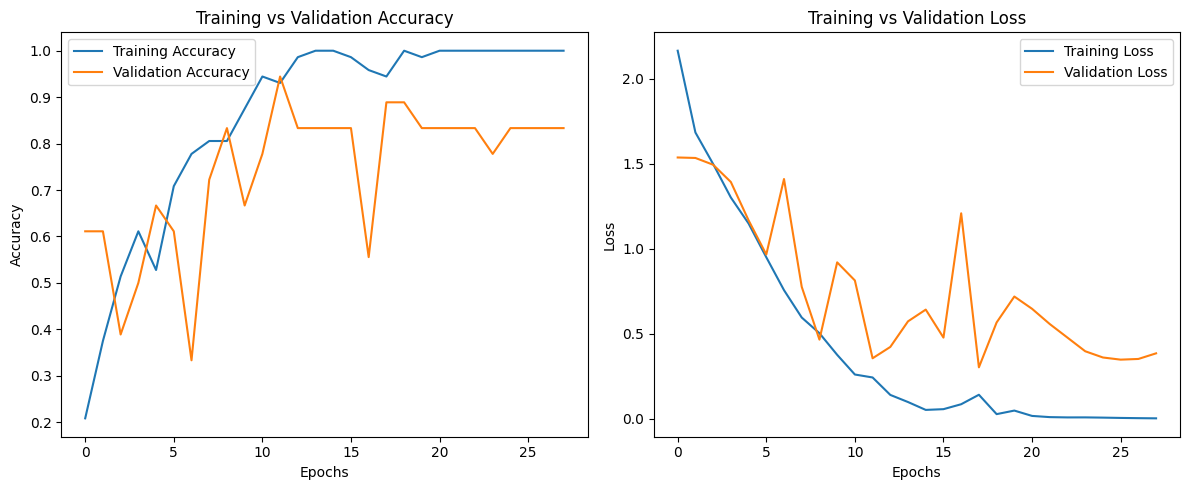

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()